# Attention

In [1]:
import torch

In [2]:
def attention(embedding_matrix: torch.Tensor, query_matrix: torch.Tensor, key_matrix: torch.Tensor, value_matrix: torch.Tensor) -> torch.Tensor:
    # -- value matrix has to map back to embeddings..!
    Q = torch.matmul(embedding_matrix, query_matrix)  # shape: batch_size x attention_dim
    K = torch.matmul(embedding_matrix, key_matrix)    # shape: batch_size x attention_dim)
    attention_scores = torch.matmul(Q, K.T) / (query_matrix.shape[0] ** (0.5))  # shape: batch_size x batch_size
    # each row represents the query of a token against all the keys including itself
    # -- we set the upper triangular to neg infinity to preventing attending of future tokens
    upper_triangular_mask = torch.triu_indices(attention_scores.shape[0], attention_scores.shape[1], offset=1) 
    attention_scores[upper_triangular_mask[0], upper_triangular_mask[1]] = - torch.inf
    attention_weights = torch.softmax(attention_scores, dim=1)
    # for each row, we now have proportions of how much attention to pay to each token in the sequence (including itself, and excluding future tokens)
    print(attention_weights)
    context_vectors = torch.matmul(attention_weights, value_matrix)

    return context_vectors



# TODO implement multi headed attention

- we split and do the calculation per head... but because we've already projected it... we are taking all features into account!

In [3]:
EMBEDDING_DIM = 4
ATTENTION_DIM = 2
VOCAB_SIZE = 3

embedding_matrix = torch.randn(VOCAB_SIZE, EMBEDDING_DIM)  # shape: batch_size x embedding_dim
query_matrix = torch.randn(EMBEDDING_DIM, ATTENTION_DIM)  # shape: embedding_dim x attention_dim
key_matrix = torch.randn(EMBEDDING_DIM, ATTENTION_DIM)    # shape
value_matrix = torch.randn(VOCAB_SIZE, EMBEDDING_DIM)  # shape: embedding_dim x attention_dim


attention(embedding_matrix, query_matrix, key_matrix, value_matrix)

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00],
        [9.9999e-01, 6.0753e-06, 0.0000e+00],
        [2.9806e-02, 3.6118e-01, 6.0901e-01]])


tensor([[-1.6453,  0.2307,  0.1555,  1.5265],
        [-1.6453,  0.2307,  0.1555,  1.5265],
        [-0.0651, -0.8804, -0.1836, -0.1101]])

# Experiment to see what attention scores are like

In [8]:
import torch
from transformers import BertTokenizer, BertModel

# Load pretrained tokenizer + model
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertModel.from_pretrained(
    model_name,
    output_attentions=True  # 👈 this is key
)


model.eval()

# Input sentence
sentence = "I love NLP. She is my girlfriend."

# Tokenize
inputs = tokenizer(sentence, return_tensors="pt")


# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Extract attention
attentions = outputs.attentions  # tuple of layers

print(f"Number of layers: {len(attentions)}")

# Example: get attention from first layer
layer_0 = attentions[0]  # shape: (batch, heads, seq_len, seq_len)

print("Shape:", layer_0.shape)

# Remove batch dimension
layer_0 = layer_0[0]

# Print attention from head 0
head_0 = layer_0[0]

print("Attention scores (head 0):")

print(head_0)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13429.66it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of layers: 12
Shape: torch.Size([1, 12, 12, 12])
Attention scores (head 0):
tensor([[0.0608, 0.0515, 0.0361, 0.0360, 0.0570, 0.1185, 0.0343, 0.0513, 0.0674,
         0.0342, 0.1269, 0.3260],
        [0.1224, 0.0860, 0.0987, 0.0548, 0.0365, 0.0459, 0.0622, 0.0398, 0.2247,
         0.1264, 0.0489, 0.0538],
        [0.1429, 0.0702, 0.0459, 0.0450, 0.0409, 0.0870, 0.0866, 0.0913, 0.0606,
         0.1253, 0.0930, 0.1113],
        [0.0125, 0.0533, 0.1407, 0.0611, 0.0757, 0.0238, 0.1393, 0.0451, 0.0848,
         0.2863, 0.0262, 0.0514],
        [0.0376, 0.0793, 0.1624, 0.1108, 0.0397, 0.0291, 0.0995, 0.0419, 0.1043,
         0.2162, 0.0293, 0.0498],
        [0.0842, 0.0579, 0.1133, 0.0616, 0.0515, 0.1227, 0.0771, 0.0707, 0.0660,
         0.0710, 0.1234, 0.1008],
        [0.0677, 0.0799, 0.0623, 0.0337, 0.0495, 0.0849, 0.1221, 0.1188, 0.1736,
         0.0797, 0.0868, 0.0410],
        [0.1104, 0.1126, 0.0864, 0.0547, 0.0440, 0.0507, 0.1581, 0.0912, 0.1152,
         0.0913, 0.0511, 0.0342

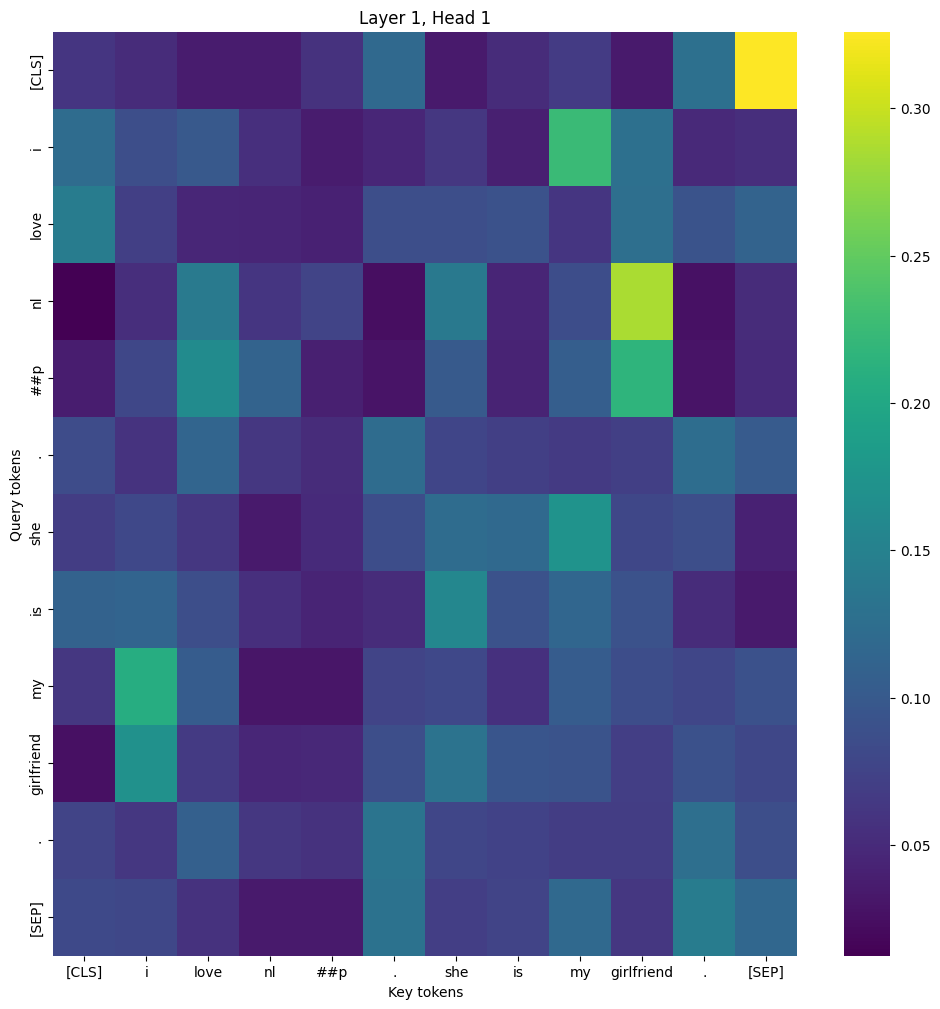

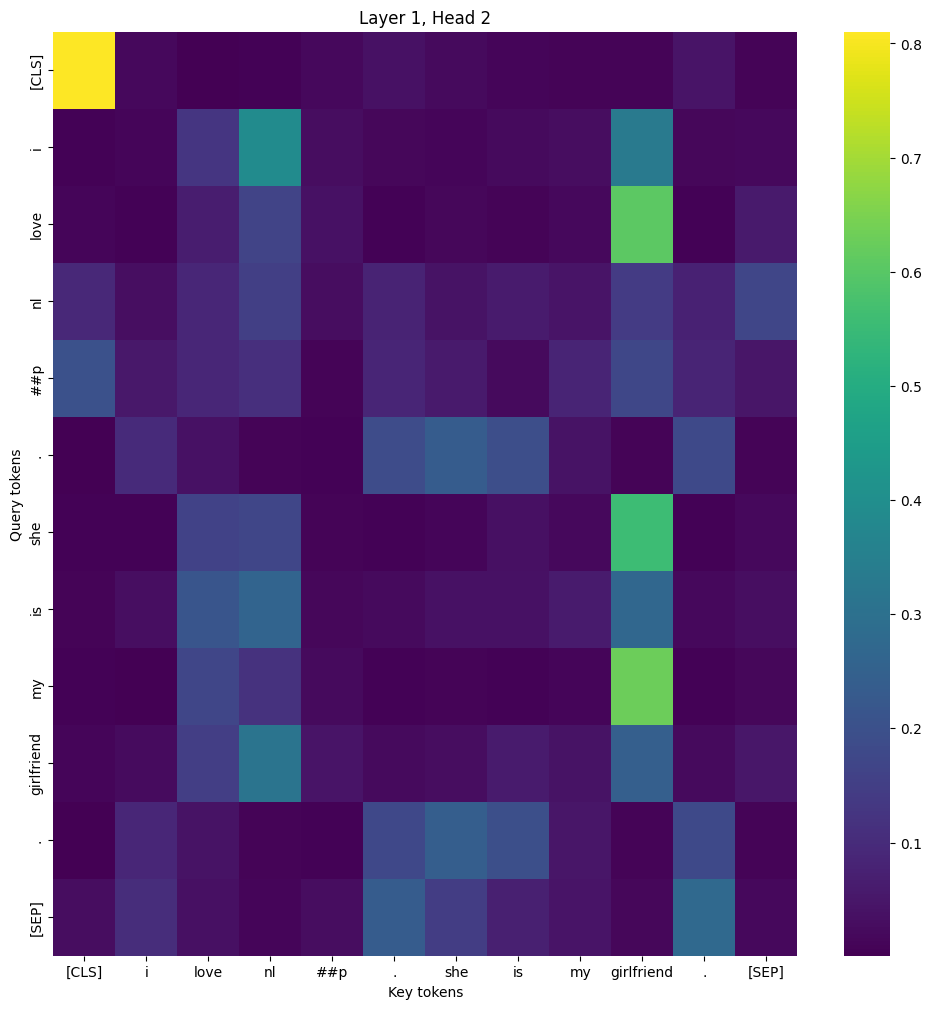

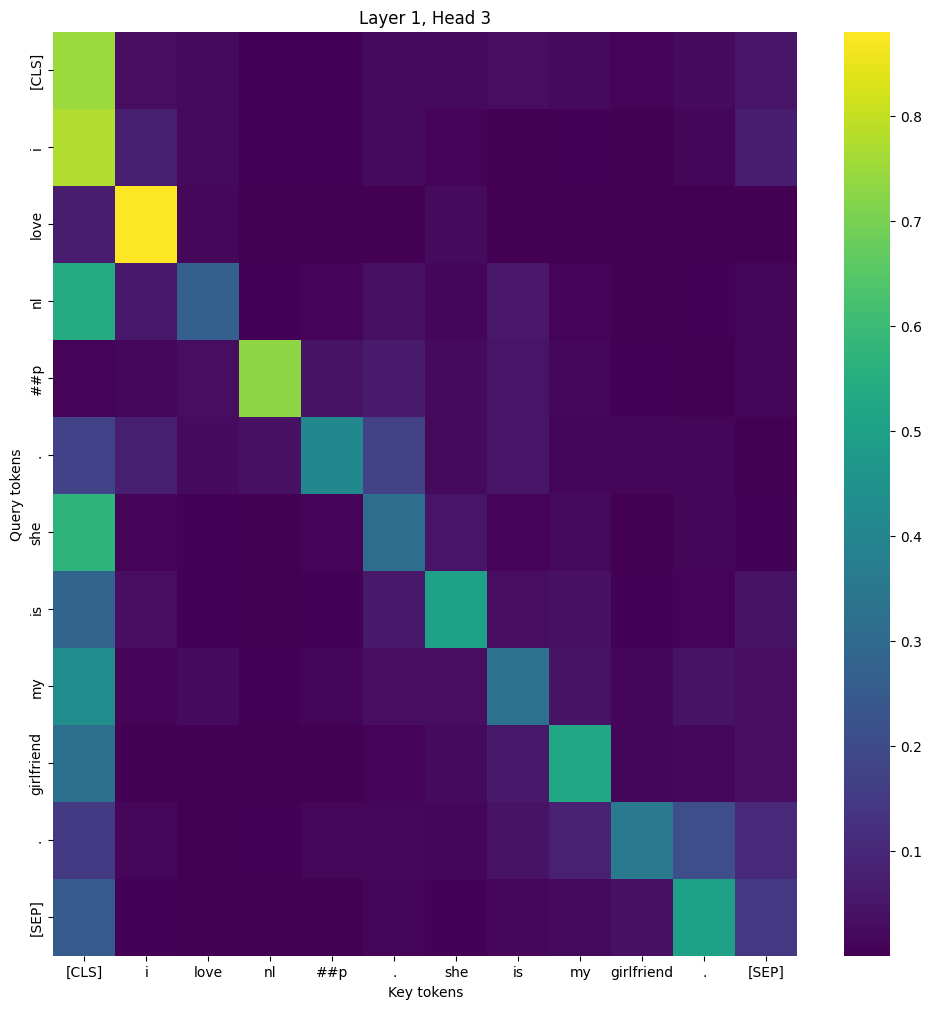

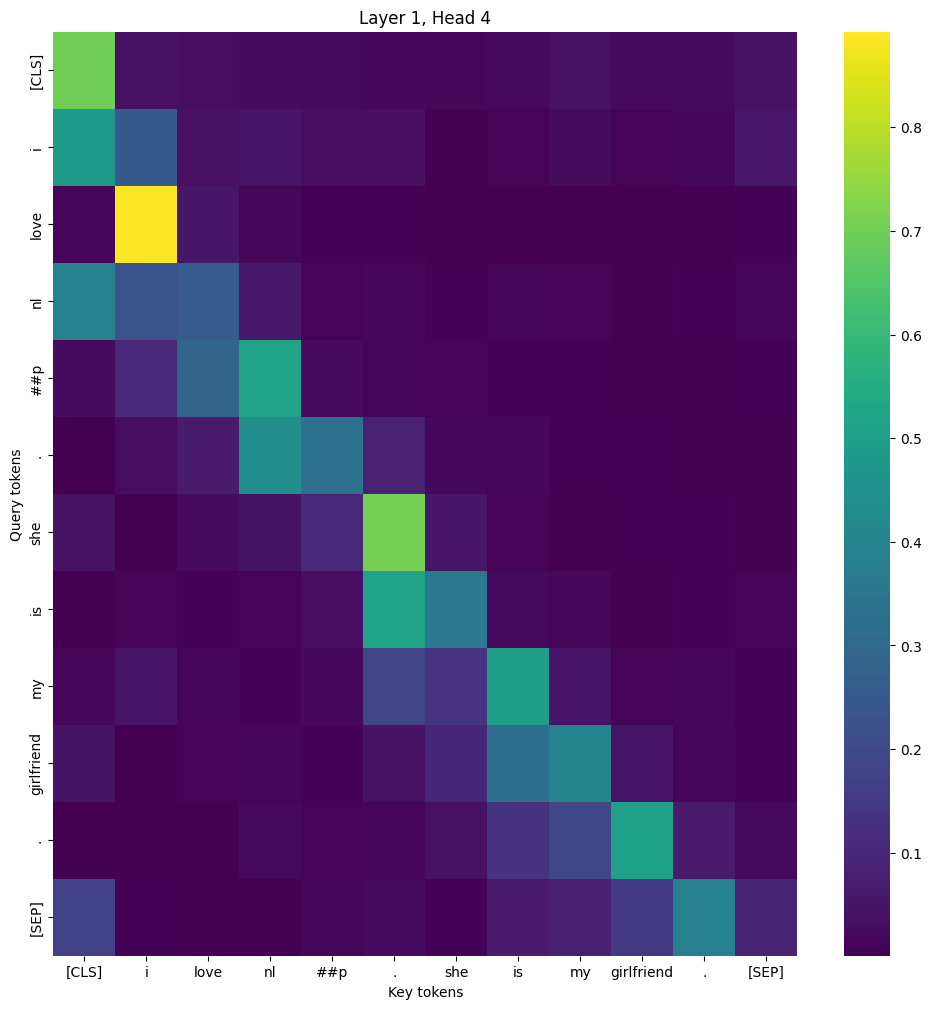

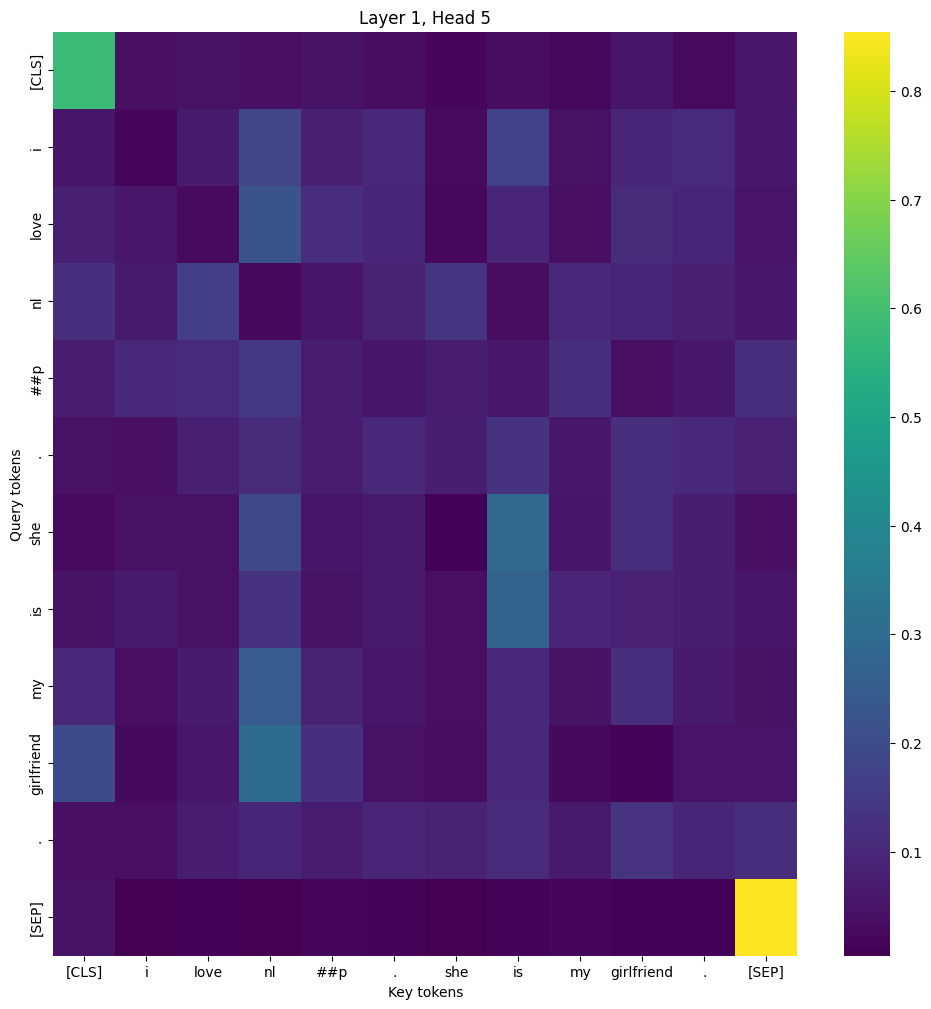

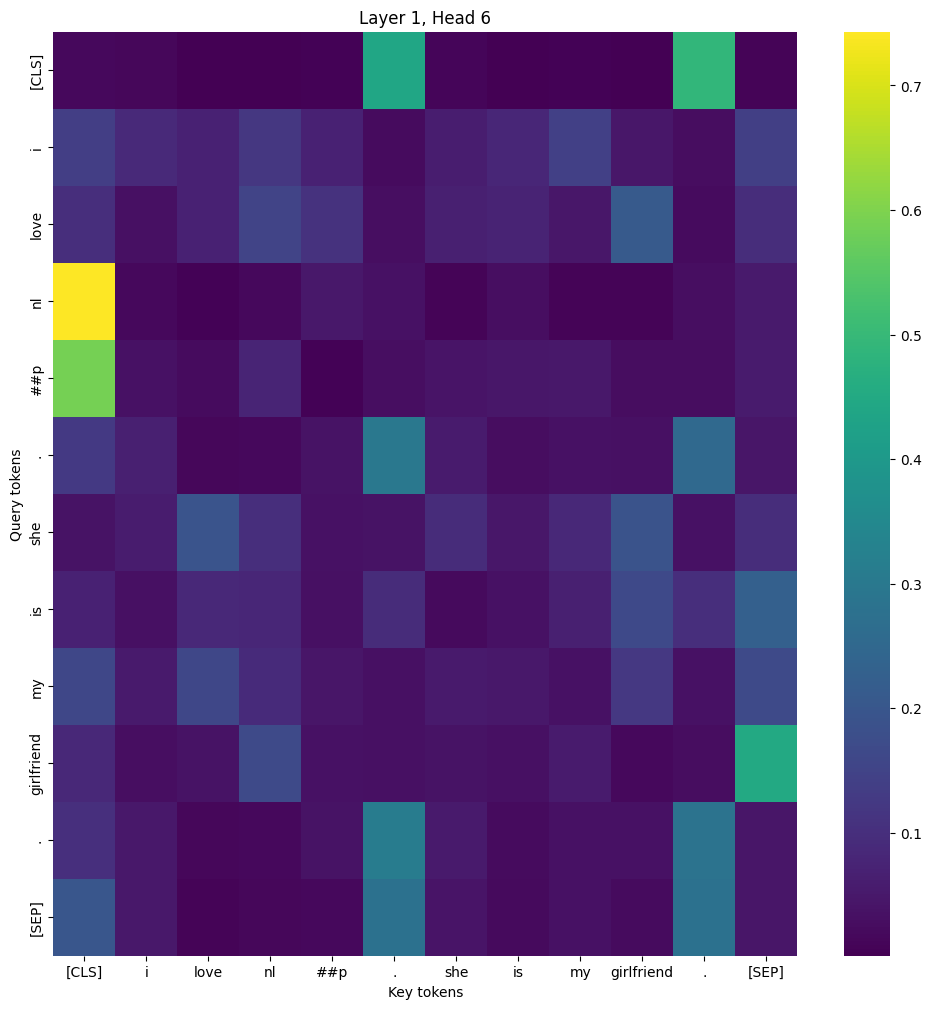

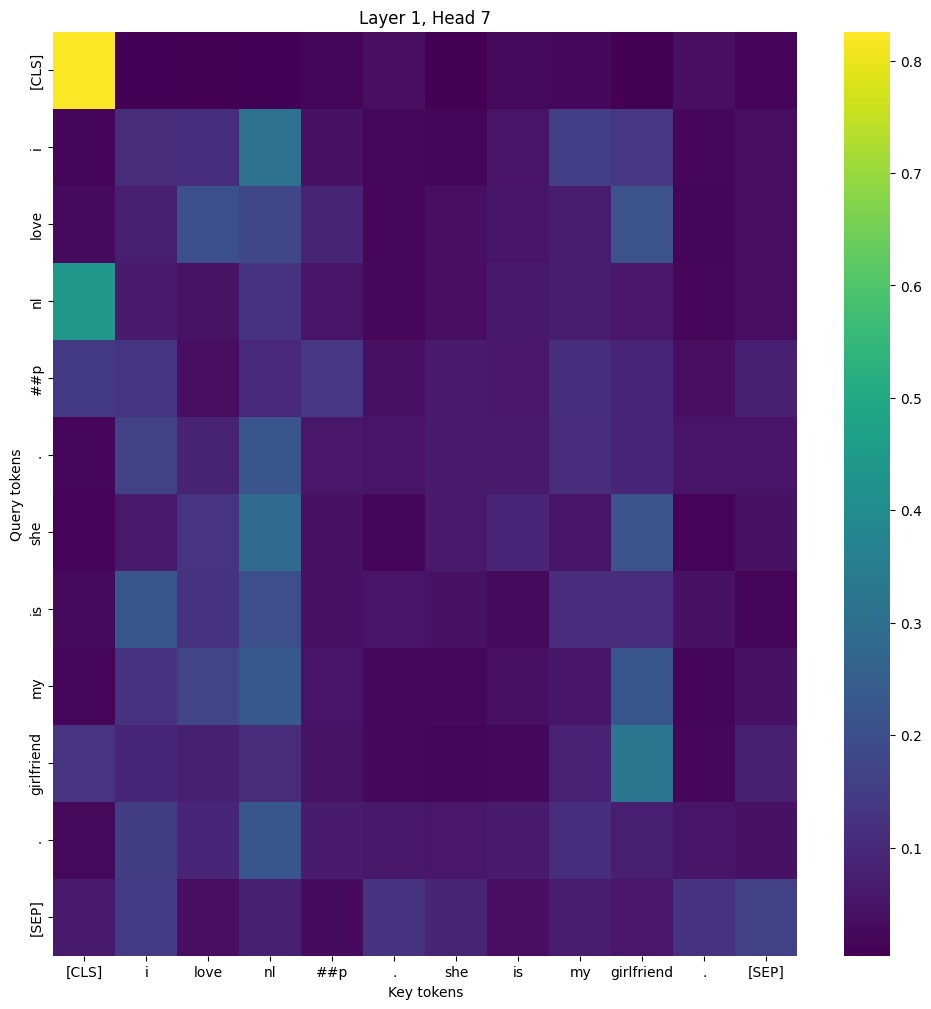

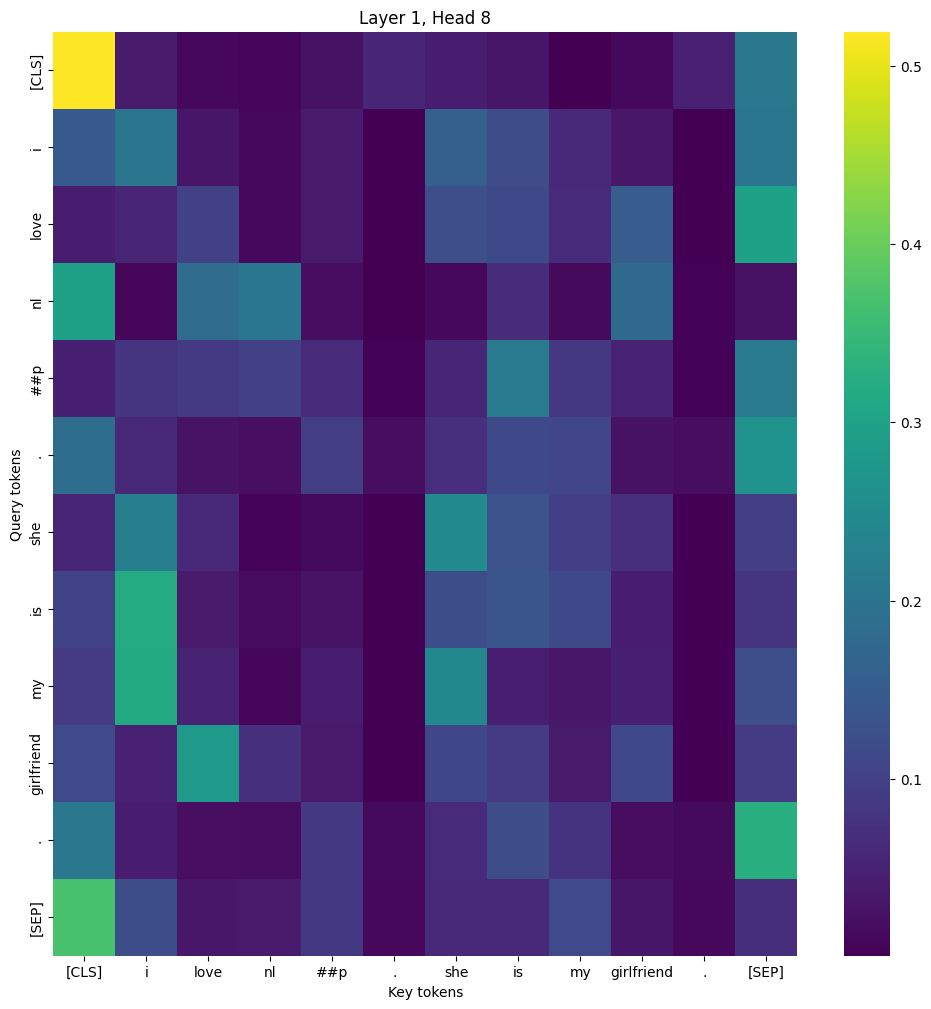

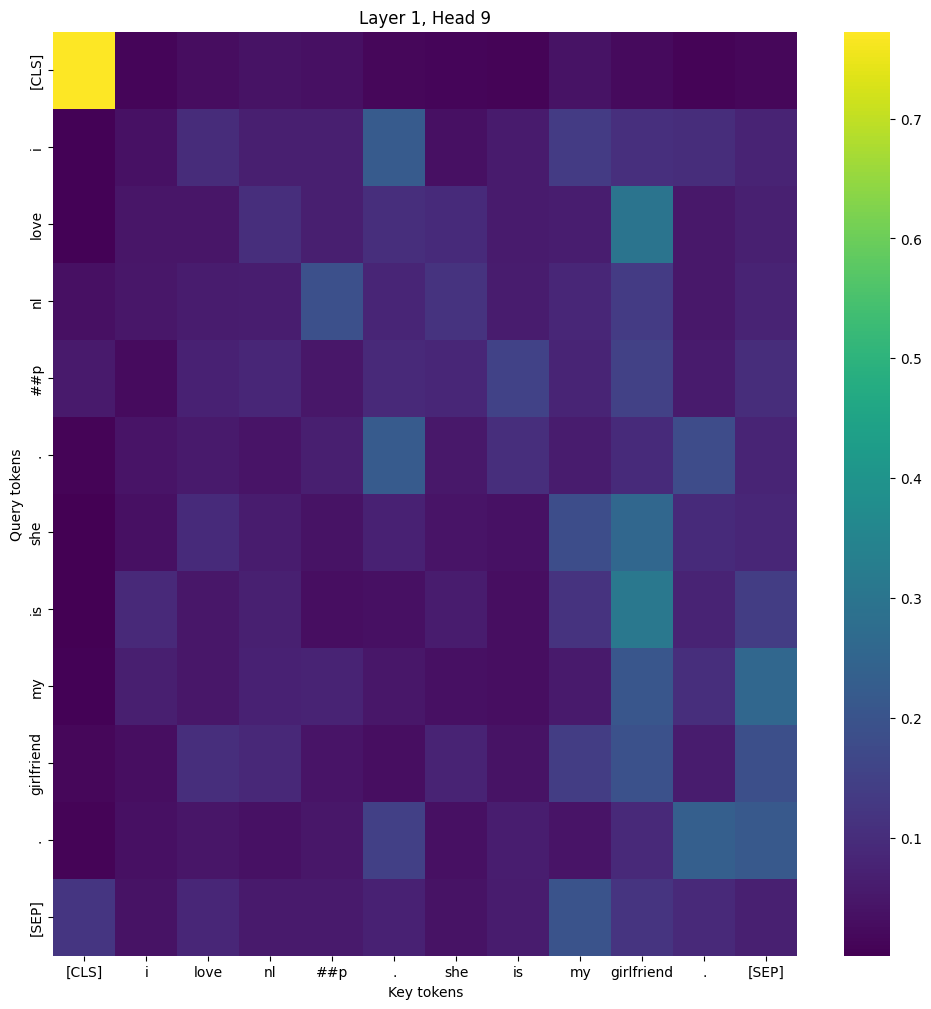

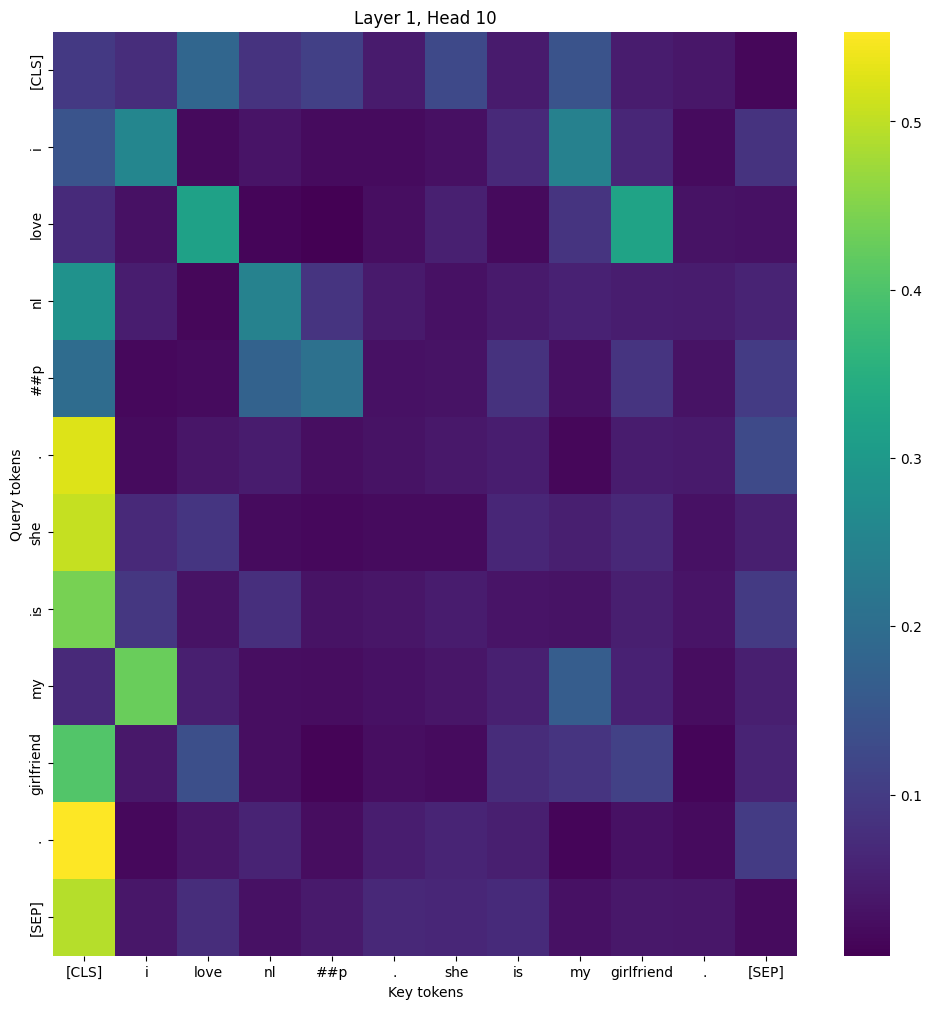

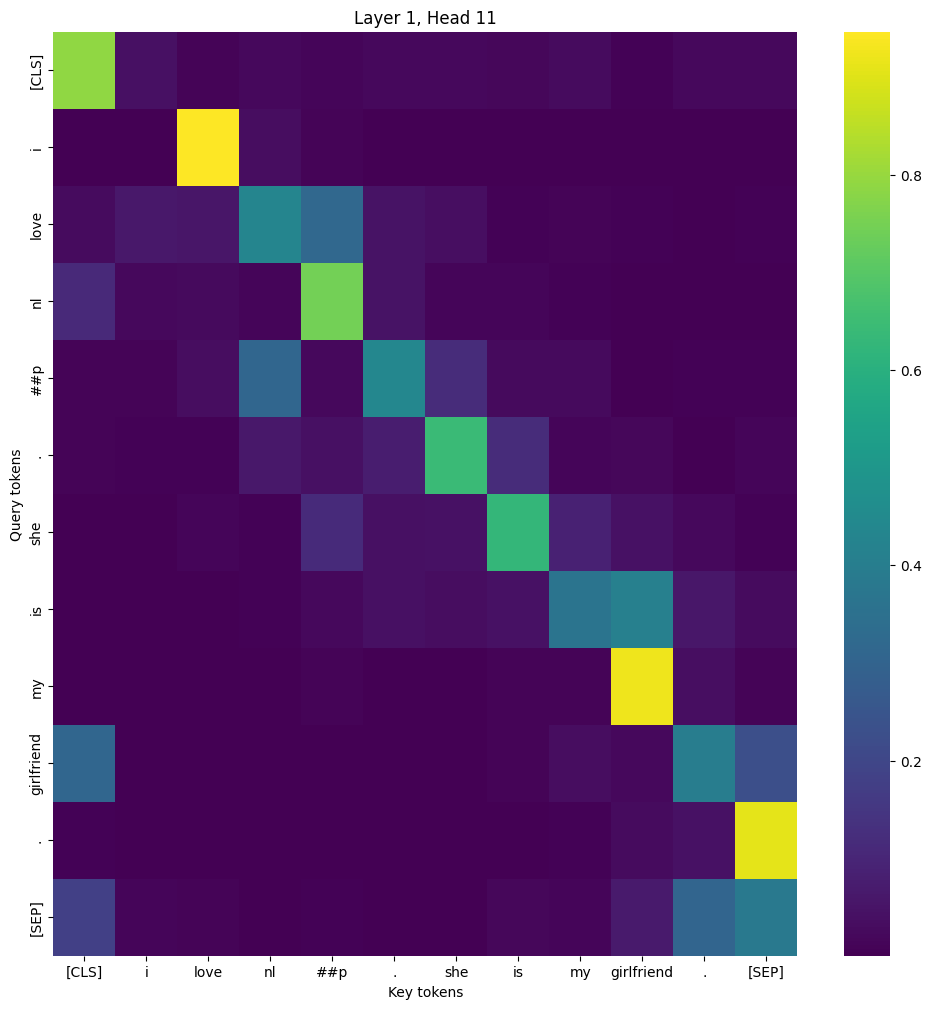

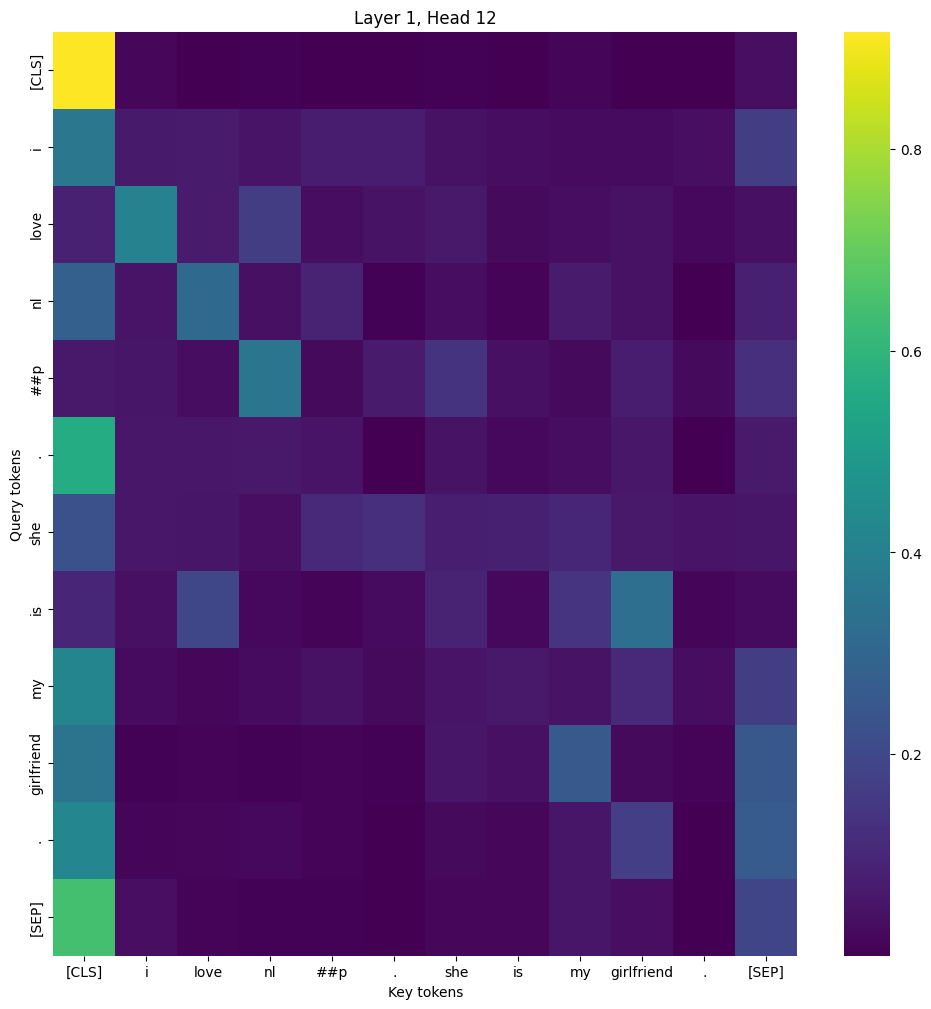

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
# For simplicity, let's visualize the first layer, first head
layer_idx = 0
# head_idx = 0

for head_idx in range(attentions[layer_idx].shape[1]):

    attn_matrix = attentions[layer_idx][0, head_idx].detach().numpy()

    plt.figure(figsize=(len(tokens), len(tokens)))
    sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Layer {layer_idx+1}, Head {head_idx+1}")
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.show()

In [32]:
model.encoder.layer[0].attention.self

BertSelfAttention(
  (query): Linear(in_features=768, out_features=768, bias=True)
  (key): Linear(in_features=768, out_features=768, bias=True)
  (value): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [20]:
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [34]:
embeddings = model.embeddings(inputs["input_ids"])
print(embeddings[0][0])

word_embeds = model.embeddings.word_embeddings(inputs["input_ids"])
print(inputs)
position_emebds = model.embeddings.position_embeddings()

tensor([ 1.6855e-01, -2.8577e-01, -3.2613e-01, -1.1222e-01,  3.4266e-02,
        -2.6894e-01, -3.0162e-02, -3.9016e-02,  1.5653e-02, -2.8276e-01,
         1.4363e-01,  4.2570e-02, -2.2034e-01, -2.2547e-03, -5.5247e-01,
         1.0922e-01, -2.1075e-02, -1.5073e-02,  7.2418e-02, -3.0336e-01,
        -2.2498e-01, -3.3294e-01, -9.4378e-02,  1.0711e-01, -1.3572e-01,
        -2.3389e-01, -1.0675e-01,  1.0395e-01, -6.7793e-02,  3.1785e-02,
        -1.9652e-01, -2.6371e-03, -2.8137e-01,  4.3571e-02, -9.4692e-02,
        -1.9646e-01, -1.0917e-01,  1.3514e-01,  1.4018e-01,  3.2562e-01,
        -2.3992e-02, -3.0597e-02, -7.7377e-02, -9.7913e-02, -1.2081e-01,
        -3.5356e-02, -3.9370e+00,  2.2336e-02,  4.6937e-01, -2.0145e-01,
         7.1337e-01,  1.6904e-01, -4.3016e-01,  1.1622e+00,  4.0043e-01,
        -1.1422e-01, -1.3014e-01, -1.0688e-01,  1.3139e-01, -3.6606e-01,
         3.2331e-03,  6.2189e-02, -6.7872e-01, -2.1598e-01,  1.9502e-02,
        -1.2909e-01,  6.4070e-02, -2.2963e-01, -3.5

TypeError: Embedding.forward() missing 1 required positional argument: 'input'

In [ ]:
# experiment - is there a benefit to purposely messing up the position embeddings? (e.g. by shuffling them) to force the model to rely more on the content of the tokens rather than their position in the sequence?
# experiment - is there a benefit in purposely messhing up the attnetion mask?